In [48]:
import numpy as np
import matplotlib.pyplot as plt

In [303]:
mass = 1.223   # solar mass
radius = 1.357   # solar radius
lum = mass**4   # solar lum
teff = 6325   # K
teff_sun = 5777   # K

In [423]:
# source: chaplin & miglio (2013)
def large_separation(mass, radius):   # Δν
    del_nu_sun = 134.91   # micro Hz  # source: lund et al (2016) (paper i)
    del_nu = del_nu_sun*(mass**(1/2))*(radius**(-3/2))
    return del_nu

In [422]:
# source: chaplin & miglio (2013)
def mode_max(mass, radius, teff, teff_sun):   # ν_max
    nu_max_sun = 3090   # micro Hz   # source: huber et al (2011)
    g = mass/(radius**2)
    nu_max = nu_max_sun*g*((teff/teff_sun)**(-1/2))
    return nu_max

In [399]:
# source: lund et al (2016)
def mode_freq(mass, radius):   # ν_nl
    order = [i for i in range(10,101)]   # n needs to be large
    degree = [i for i in range(0,4)]   # l only observable up to l<4
    epsilon = 1.55   # joel found this
    del_nu = large_separation(mass, radius)
    D_0 = 0.05*del_nu
    
    # asymptotic relation
    modes = []
    for l in degree:
        for n in order:
            nu_nl = (n + l/2 + epsilon)*del_nu - l*(l + 1)*D_0
            modes.append((n, l, nu_nl))
    modes = np.array(modes, dtype=[("n", int), ("l", int), ("nu", float)])
    frequencies = np.array(modes["nu"])
    return frequencies

In [412]:
# source: ball et al (2018)
# maximum rms amplitude
def amp_rms_max(mass, teff, teff_sun):
    tred = 8907*(lum)**(-0.093)
    del_T = 1250
    beta = 1-np.exp((teff-tred)/del_T)
    amp_max = 2.1*beta*lum*(1/mass)*((teff/teff_sun)**(-2))
    return amp_max

"\ndifference from joel's\nmine uses t_red_star as 8907, while his uses 8900\n# i don't know why beyond approximation, since we both use ball et al (2018) which uses 8907\n"

In [1]:
# source: ball et al (2018)
def fwhm_envelope(mass, radius, teff, teff_sun):
    nu_max = mode_max(mass, radius, teff, teff_sun)   # float
    fwhm_env = (0.66)*((nu_max)**0.88)   # float
    if teff>teff_sun:
        fwhm_env = (1 + 6e-4*(teff-teff_sun))*fwhm_env
    return fwhm_env   # float

In [402]:
# source: ball et al (2018)
def amp_rms_nl_square(mass, radius, teff, teff_sun):
    nu_max = mode_max(mass, radius, teff, teff_sun)   # float
    fwhm_env = fwhm_envelope(mass, radius, teff, teff_sun)   # float
    sig_env = fwhm_env/(2*np.sqrt(2*np.log(2)))   # float
    nu_nl = mode_freq(mass, radius)   # array
    amp_max = amp_rms_max(mass, teff, teff_sun)   # float
    amp_nl=(amp_max**2)*np.exp(-((nu_nl-nu_max)**2)/(2*(sig_env**2)))   # array
    return amp_nl

'\ndifference:\nmine returns a squared amplitude, while his returns a normal amplitude\n-----------------------\n    star_rms_amplitude = (((self.star_max_rms_amplitude_radial ** 2) * np.exp(-((nu_nl-self.star_nu_max)**2)/(2*(self.star_standev_envelop**2))))**0.5)\n-----------------------\n'

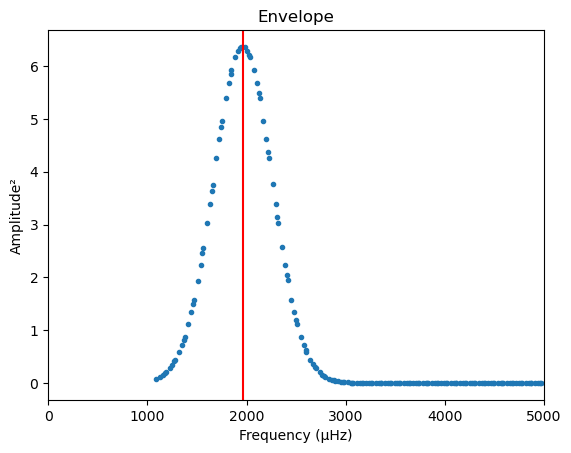

In [404]:
# CHECK: envelope
mode_frequency = mode_freq(mass, radius)
plt.plot(mode_frequency, amp_rms_nl_square(mass, radius, teff, teff_sun), '.')
plt.axvline(mode_max(mass, radius, teff, teff_sun), color='r')
plt.xlabel("Frequency (μHz)")
plt.ylabel("Amplitude²")
plt.xlim(0,5000)
plt.title("Envelope")
plt.show()

In [405]:
# source: yang (2018)
def linewidths(mass, radius, teff, teff_sun):
    width_sun = 0.95   # micro Hz (baudin et al 2011)
    del_nu_ratio = (mass**(1/2))*(radius**(-3/2))
    # f_param is a free parameter in range 1-5, with mean of 3 (yang 2018)
    # this can be refined so f is actually a free parameter, rather than fixed at its mean for simplicity
    f_param = 1
    if mass > 1.2:
        f_param = 3
    gamma = f_param*(mass*radius)*del_nu_ratio*((teff/teff_sun)**3)*width_sun
    return gamma

'\ndifference:\nthey use ball et al (2018) while i use yang (2018)\n------------------------\n        self.alpha = self.calc_width_parameter(2.95, 0.39)\n        self.width_alpha = self.calc_width_parameter(3.08, 3.32)\n        self.delta_width_dip = self.calc_width_parameter(-0.47, 0.62)\n        self.W_dip = self.calc_width_parameter(4637, -141)\n        self.nu_dip = self.calc_width_parameter(2984, 60)\n\n        def calc_width_parameter(self, a, b):\n            width_param = a*(self.nu_max_ratio) + b    # a and b are constants\n            return width_param\n\n        def calc_width_nl(self, n, l):\n            nu_nl = self.calc_nu_nl(n,l)\n            line_width = ((self.alpha * np.log(nu_nl / self.star_nu_max)) + np.log(self.width_alpha)) + (np.log(self.delta_width_dip)/(1 + (((2 * np.log(nu_nl/self.nu_dip))/(np.log(self.W_dip/self.star_nu_max)))**2)))\n            width_nl = np.exp(line_width)\n            return width_nl\n------------------------\n'

In [406]:
# source: chaplin & miglio (2013), lund et al (2016), ball et al (2018)
def height_nl(mass, radius, teff, teff_sun):
    amp_nl = amp_rms_nl_square(mass, radius, teff, teff_sun)   # array
    lw_nl = linewidths(mass, radius, teff, teff_sun)   # array
    # visibilities
    # source: ball et al (2018)
    v1=1.505
    v2=0.620
    v3=0.075
    # mode frequencies have a repeating pattern in my code:
    # they are calculated in 90-item chunks of the same l but changing n
    # thus multiples of 90 give l=0,1,2,3
    amp_n1 = amp_nl[91:(2*91)]*v1
    amp_n2 = amp_nl[(2*91):(3*91)]*v2
    amp_n3 = amp_nl[(3*91):(4*91)]*v3
    amp_n = amp_nl
    amp_n[(91):(2*91)] = amp_n1
    amp_n[(2*91):(3*91)] = amp_n2
    amp_n[(3*91):(4*91)] = amp_n3
    return 2*amp_n/(np.pi*lw_nl)

'\ndifference:\nnone\n-----------------------\ndef calc_power_amplitude(amp,width):\n    x = (2/np.pi)*((amp**2)/width)\n    return x \n-----------------------\n'

In [419]:
# source: spectrum basics
def power_spec(mass, radius, teff, teff_sun):
    height = height_nl(mass, radius, teff, teff_sun)
    g = (mass/(radius**2))
    lw_nl = linewidths(mass, radius, teff, teff_sun)
    nu_nl = mode_freq(mass, radius)
    nu_ac_sun = 5000   # micro Hz (Jimenez et al 2011)
    nu_ac = nu_ac_sun*g*((teff/teff_sun)**(-1/2))   # micro Hz (Chaplin & Miglio 2013)
    #nu_ac = c/(4*np.pi*H)
    #c = nu_ac*4*np.pi*height
    nu_min = 100   # micro Hz
    nu = np.linspace(nu_min, nu_ac, 10000)
    power_of_nu = []
    for v in nu:
        nl_sum = 0
        for nl in range(len(nu_nl)):
            p_iter = height[nl]*((lw_nl/2)**2/((v-nu_nl[nl])**2 + (lw_nl/2)**2))
            nl_sum += p_iter
        power_of_nu.append(nl_sum)
    return nu, power_of_nu

"\ndifference from joel's:\nmine uses arbitrary small value of nu_min as the min and uses nu_ac as the max\njoel's uses a 3sigma deviation from nu_max for the min and max, for each angular degree\nwe use the same lorentz curve formula\n-----------------------\n    nu_envelope_min = self.star_nu_max - (3*self.star_standev_envelop)\n    nu_envelope_max = self.star_nu_max + (3*self.star_standev_envelop)\n    for i in self.angular_degree:\n        n_min.append(int((nu_envelope_min/self.star_delta_nu) - ((i/2) + self.epsilon)))\n        n_max.append(int((nu_envelope_max/self.star_delta_nu) - ((i/2) + self.epsilon)))\n------------------------\n    x = ((FWHM/2)**2 / ((freq - centroid)**2 + (FWHM/2)**2))\n------------------------\n"

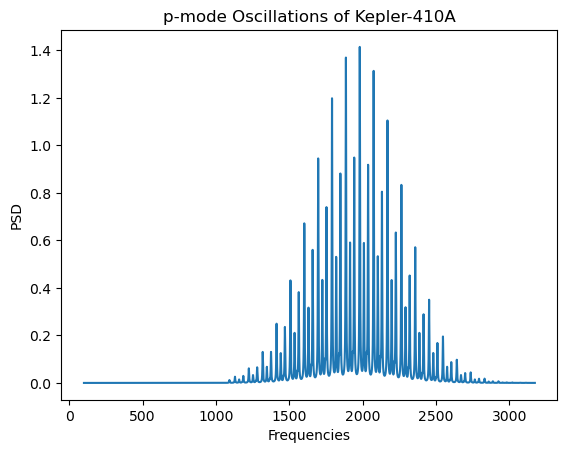

In [420]:
frequencies, powers = power_spec(mass, radius, teff, teff_sun)
plt.plot(frequencies, powers)
plt.xlabel("Frequencies")
plt.ylabel("PSD")
plt.title("p-mode Oscillations of Kepler-410A")
plt.show()

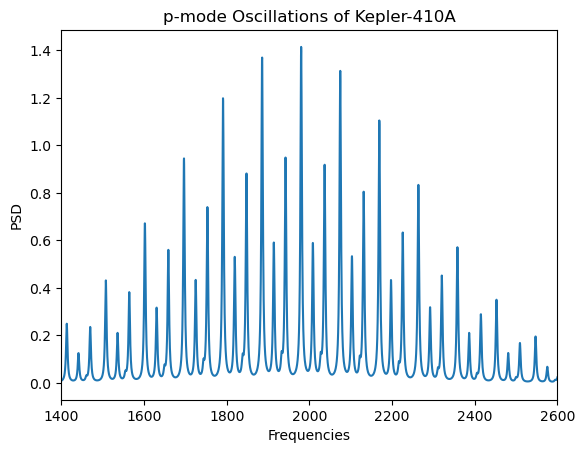

In [421]:
frequencies, powers = power_spec(mass, radius, teff, teff_sun)
plt.plot(frequencies, powers)
plt.xlabel("Frequencies")
plt.ylabel("PSD")
plt.title("p-mode Oscillations of Kepler-410A")
plt.xlim(1400,2600)
plt.show()